# Coherent Phonon Graphs

**Import Libraries**

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np
from helpers import process

**Download Files**

In [21]:
metal = "antimony" # Choose metal (bismuth or antimony)

# Baseline length
baseline_num = 5


t0 = 139.18162010600014

files = glob.glob(f"{metal}/data/*.txt") # Download files
files = sorted(files, key=lambda f: float(f.rsplit('.', 1)[0].rsplit('/', 1)[1]))
# files = sorted(files) # Sort files

**Process and Plot Data**

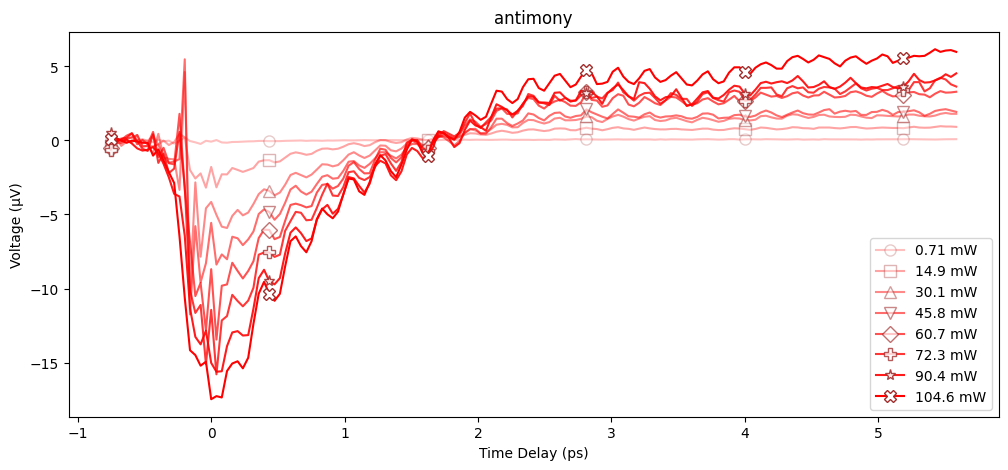

In [22]:
fig = plt.figure(figsize=(12, 5))  # wider figure, same data range
n = len(files)

markers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', '<', '>']

for i, file in enumerate(files):
    f = file.rsplit('.', 1)[0]
    power = f.rsplit('/', 1)[1]
    voltage, time = process(metal, power, baseline_num)

    time = time - t0

    alpha = 0.25 + 0.75 * (i / (n - 1)) if n > 1 else 1.0
    plt.plot(time, voltage,
             color='red', alpha=alpha,
             marker=markers[i % len(markers)],
             markevery= 30,           # every 15th point gets a marker
             markerfacecolor='white',
             markeredgecolor='#A32D2D',
             markersize=8,
             label=f"{power} mW")
plt.title(f"{metal}")
plt.xlabel("Time Delay (ps)")
if metal == "bismuth":
    plt.ylabel("(\u0394R/R)%")
else:
    plt.ylabel("Voltage (\u00B5V)")
plt.legend()
plt.show()

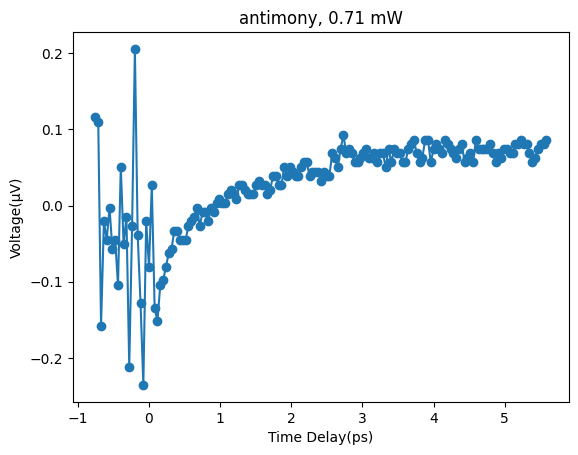

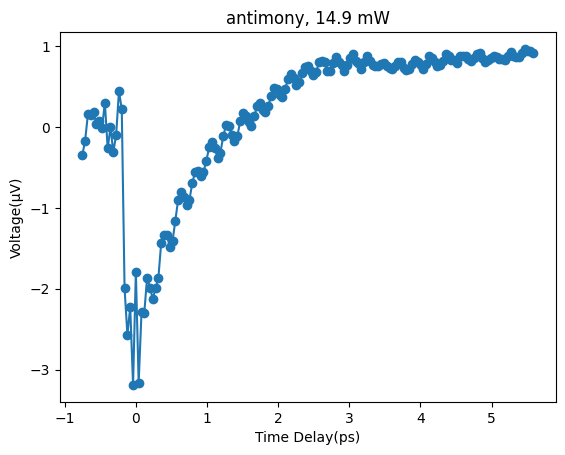

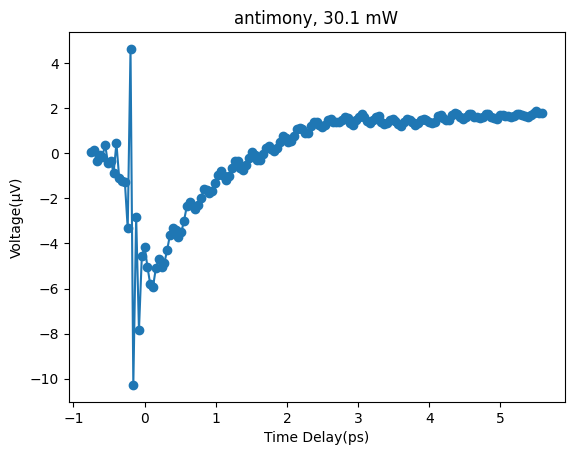

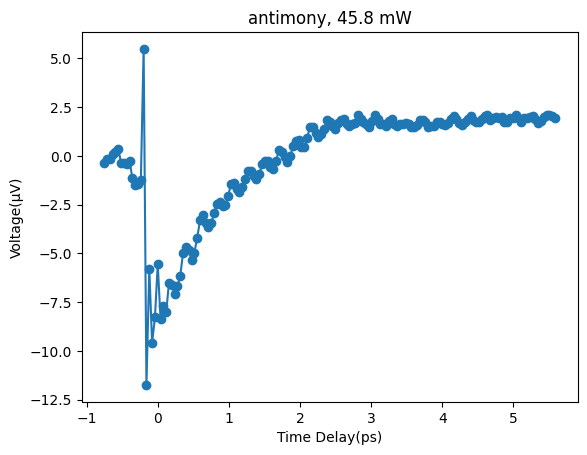

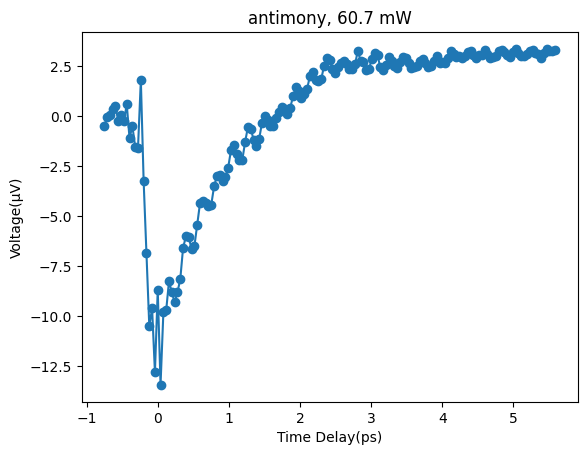

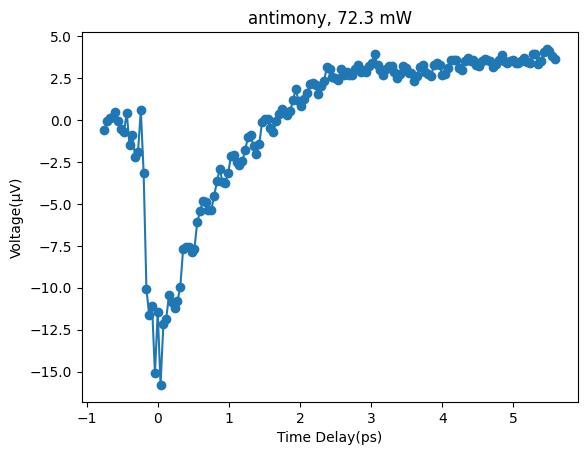

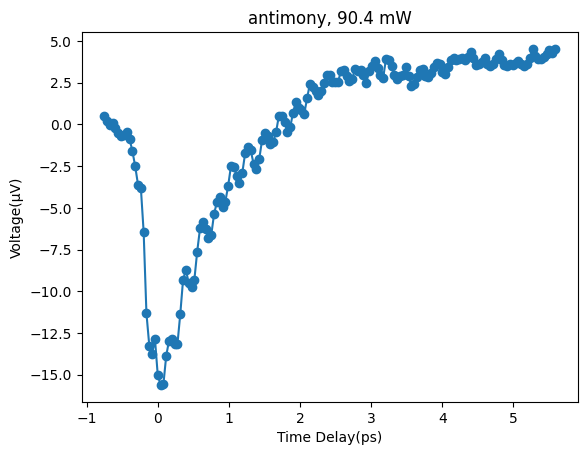

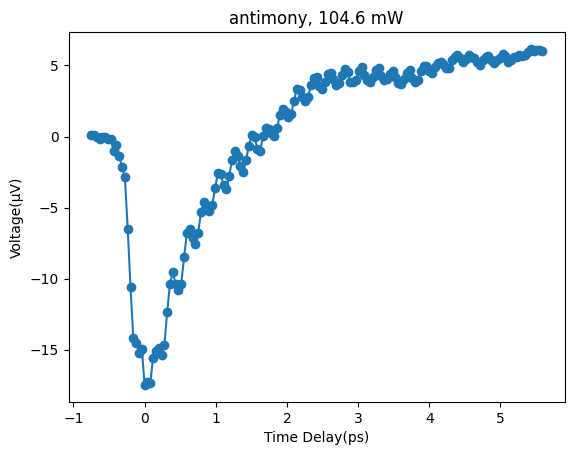

In [23]:
for file in files:
    f = file.rsplit('.', 1)[0]
    power = f.rsplit('/', 1)[1]

    voltage, time = process(metal, power, baseline_num)
    time = time - t0

    plt.figure()
    plt.plot(time, voltage)
    plt.scatter(time, voltage)
    plt.xlabel("Time Delay(ps)")
    if metal == "bismuth":
        plt.ylabel(f"(\u0394R/R)%")
    else:
        plt.ylabel(f"Voltage(\u00B5V)")
    plt.title(f"{metal}, {power} mW")

    plt.savefig(f"{metal}_{power}.pdf")
    
    plt.show()
